In [1]:
import os
import math

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
nstep = pd.read_excel("./data/mCALR-N step data-17mar2026.xlsx", header = 1)
nstep = nstep[2:].reset_index(drop = True)
nstep.columns = ["Batch"] + nstep.columns.tolist()[1:]

nstep_ts = pd.read_excel("./data/mCALR-N step data-17mar2026.xlsx", sheet_name = 1, header = 1)
nstep_ts.insert(0, "Batch", nstep_ts["Run"].apply(lambda x: x.split("_")[0]))

nstep_ts_start = nstep_ts[["Batch", "Process Time [h]"]].groupby("Batch").min().reset_index()
nstep_ts_start.columns = ["Batch", "Process Start Time"]

nstep_ts = pd.merge(nstep_ts_start, nstep_ts, on = "Batch")
nstep_ts["Process Time [h]"] -= nstep_ts["Process Start Time"]
nstep_ts.insert(3, "Process Day", nstep_ts["Process Time [h]"].apply(lambda x: math.ceil((x - 12)/24)))
nstep_ts.drop("Process Start Time", axis = 1, inplace = True)

nminusstep_ts = pd.read_excel("./data/mCALR N-1.xlsx", sheet_name = 1)
nminusstep_ts.insert(0, "Batch", nminusstep_ts["Run"].apply(lambda x: x.split("_")[0]))

nminusstep_ts_start = nminusstep_ts[["Batch", "Process Time [h]"]].groupby("Batch").min().reset_index()
nminusstep_ts_start.columns = ["Batch", "Process Start Time"]

nminusstep_ts = pd.merge(nminusstep_ts_start, nminusstep_ts, on = "Batch")
nminusstep_ts["Process Time [h]"] -= nminusstep_ts["Process Start Time"]
nminusstep_ts.insert(3, "Process Day", nminusstep_ts["Process Time [h]"].apply(lambda x: math.ceil((x - 12)/24)))
nminusstep_ts.drop("Process Start Time", axis = 1, inplace = True)

In [3]:
nstep_ts.head(3)

,Batch,Run,Process Day,Process Time [h],Ammonia [mg/L],Bolus Feed A Daily Qty [kg],Bolus Glucose Daily Qty [kg],Bolus Feed B Daily Qty [kg],Glucose [mg/L],Glutamate [mg/L],...,Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],Online pH secondary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pH offset [],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
0,FA001,FA001_MCALR N-PROD 2000L_1003145,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7.04,NaN,NaN,NaN,NaN,NaN,NaN
1,FA001,FA001_MCALR N-PROD 2000L_1003145,0,0.003056,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.05,NaN,NaN,NaN,NaN,NaN
2,FA001,FA001_MCALR N-PROD 2000L_1003145,0,0.099722,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,7.047,NaN,NaN,NaN,-0.067209,NaN,NaN,NaN


In [4]:
nstep_ts.groupby(["Batch", "Process Day"]).max().reset_index()

,Batch,Process Day,Run,Process Time [h],Ammonia [mg/L],Bolus Feed A Daily Qty [kg],Bolus Glucose Daily Qty [kg],Bolus Feed B Daily Qty [kg],Glucose [mg/L],Glutamate [mg/L],...,Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],Online pH secondary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pH offset [],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
0,FA001,0,FA001_MCALR N-PROD 2000L_1003145,7.383889,2.558,40.98,NaN,4.098,4798.96,102.85,...,214.43,113.8,7.047,7.04,7.05,101.0,-0.048199,136.1,7.53,91.5
1,FA001,1,FA001_MCALR N-PROD 2000L_1003145,28.489167,32.103,40.96,NaN,4.097,3288.72,383.90,...,2060.12,362.3,6.896,6.99,7.00,40.0,0.075332,32.1,12.03,89.0
2,FA001,2,FA001_MCALR N-PROD 2000L_1003145,51.487222,23.325,40.98,NaN,4.098,2767.70,503.73,...,1799.49,560.5,6.838,6.95,6.95,38.9,0.052195,15.1,19.19,89.7
3,FA001,3,FA001_MCALR N-PROD 2000L_1003145,73.599722,18.810,40.96,NaN,4.099,2161.62,546.30,...,1662.90,786.6,6.911,6.96,6.96,46.6,-0.010365,16.3,22.11,89.4
4,FA001,4,FA001_MCALR N-PROD 2000L_1003145,98.765556,20.666,40.98,9.66,4.098,1435.24,419.53,...,1114.41,1076.4,6.982,7.02,7.01,63.2,-0.021498,12.2,23.43,87.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,FA011,10,FA011_MCALR N-PROD 2000L_1004660,242.462222,136.388,46.40,12.60,4.635,1417.70,201.47,...,270.64,3832.5,6.990,7.05,7.05,150.0,0.000020,10.0,19.36,67.2
161,FA011,11,FA011_MCALR N-PROD 2000L_1004660,265.489167,130.870,46.40,NaN,4.634,2989.85,288.58,...,663.81,4231.6,6.960,7.04,7.03,130.2,NaN,10.0,17.35,62.0
162,FA011,12,FA011_MCALR N-PROD 2000L_1004660,289.369444,120.286,46.40,14.62,4.636,1218.24,367.30,...,1084.11,4852.7,6.938,7.03,7.03,92.8,NaN,14.4,17.28,57.0
163,FA011,13,FA011_MCALR N-PROD 2000L_1004660,315.898056,111.709,46.40,10.09,4.634,2351.06,463.96,...,2617.30,5296.8,6.699,6.87,6.87,38.6,NaN,21.7,14.00,49.6


In [5]:
nminusstep_ts.head(3)

,Batch,Run,Process Day,Process Time [h],Ammonia [mg/L],Glucose [mg/L],Glutamate [mg/L],Glutamine [mg/L],Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
0,FA001,FA001_MCALR N-1 STR200L_1003102,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.13,NaN,NaN,NaN,NaN
1,FA001,FA001_MCALR N-1 STR200L_1003102,0,0.017778,NaN,NaN,NaN,NaN,NaN,NaN,7.091,NaN,NaN,NaN,NaN,NaN
2,FA001,FA001_MCALR N-1 STR200L_1003102,0,0.019722,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,106.0,NaN,NaN,NaN


In [6]:
nminusstep_ts.columns

Index(['Batch', 'Run', 'Process Day', 'Process Time [h]', 'Ammonia [mg/L]',
       'Glucose [mg/L]', 'Glutamate [mg/L]', 'Glutamine [mg/L]',
       'Lactate [mg/L]', 'LDH [dimensionless]',
       'Offline pH preadusjtement [dimensionless]',
       'Online pH primary probe preadusjtement [dimensionless]',
       'pCO2 preadusjtement [mmHg]', 'pO2 preadusjtement [mmHg]',
       'VCD [Mc/mL]', 'Viability [%]'],
      dtype='object')

In [7]:
cols = ["Batch", "Process Day", "Offline pH preadusjtement [dimensionless]", "pCO2 preadusjtement [mmHg]", "Glutamate [mg/L]"]
sub_df = nminusstep_ts.groupby(["Batch", "Process Day"]).max().reset_index()
sub_df = sub_df[cols]
sub_df = sub_df[sub_df["Process Day"] == 7]
sub_df.drop("Process Day", axis = 1, inplace = True)
sub_df = sub_df.reset_index(drop = True)
sub_df.columns = ["Batch", "Offline pH", "pCO2", "Glutamate"]
sub_df

cols = ["Batch", "Process Day", "Offline pH preadusjtement [dimensionless]", "pCO2 preadusjtement [mmHg]", "Glutamate [mg/L]"]
ave_df = nminusstep_ts[nminusstep_ts["Process Day"] >= 5]
ave_df = ave_df.groupby(["Batch", "Process Day"]).max().reset_index()
ave_df = ave_df[cols]
ave_df = ave_df.groupby(["Batch"]).mean().reset_index()
ave_df.drop("Process Day", axis = 1, inplace = True)
ave_df = ave_df.reset_index(drop = True)
ave_df.columns = ["Batch", "Offline pH", "pCO2", "Glutamate"]
ave_df

n1_df = pd.merge(sub_df, ave_df, on = "Batch", suffixes = (" LAST DAY", " D5-D7 AVE"))
n1_df

,Batch,Offline pH LAST DAY,pCO2 LAST DAY,Glutamate LAST DAY,Offline pH D5-D7 AVE,pCO2 D5-D7 AVE,Glutamate D5-D7 AVE
0,FA001,6.849,85.0,0.48,6.878000,80.666667,301.423333
1,FA002,6.854,99.5,0.00,6.877333,92.233333,311.050000
2,FA003,6.814,95.4,0.00,6.870000,80.933333,297.520000
3,FA004,6.877,80.2,-5.25,6.896667,73.266667,279.076667
4,FA005,6.787,98.1,-0.69,6.855667,75.600000,324.816667
5,FA006,6.868,72.2,10.12,6.893333,67.066667,334.613333
6,FA007,6.868,82.1,2.07,6.891667,75.366667,320.320000
7,FA008,6.882,80.1,17.00,6.890667,77.700000,324.826667
8,FA009,6.882,76.4,15.37,6.893667,72.866667,546.700000
9,FA010,6.896,73.5,16.54,6.914000,70.100000,415.016667


In [8]:
cols = ["Batch", "Process Day", "Offline pH preadusjtement [dimensionless]", "pCO2 preadusjtement [mmHg]", "Glutamate [mg/L]"]

final_df = None
for day in range(6):
    sub_df = nstep_ts.groupby(["Batch", "Process Day"]).max().reset_index()
    sub_df = sub_df[sub_df["Process Day"] == day]
    sub_df = sub_df[["Batch", "VCD [Mc/mL]"]]
    sub_df.columns = ["Batch", f"VCD Day {day}"]
    sub_df = sub_df.reset_index(drop = True)

    if final_df is None:
        final_df = sub_df.copy()
    else:
        final_df = pd.merge(final_df, sub_df, on = "Batch")

final_df

ivcd = pd.read_csv("./data/IVCD mCALR batches.csv", header = 1).T.reset_index()
ivcd = ivcd[1:]
ivcd.columns = ["Batch"] + [f"IVCD Day {i+1}" for i in range(14)]
ivcd = ivcd[["Batch", "IVCD Day 4", "IVCD Day 8"]]
ivcd

n_df = pd.merge(final_df, ivcd, on = "Batch")
n_df

,Batch,VCD Day 0,VCD Day 1,VCD Day 2,VCD Day 3,VCD Day 4,VCD Day 5,IVCD Day 4,IVCD Day 8
0,FA001,7.53,12.03,19.19,22.11,23.43,22.27,66.900000,151.940000
1,FA002,7.59,12.63,19.50,24.96,24.37,24.76,71.747344,168.595042
2,FA003,7.47,12.50,17.12,24.50,24.92,24.70,68.033330,163.767955
3,FA004,7.30,11.84,18.74,22.97,27.96,29.93,69.970358,176.971701
4,FA005,6.95,13.82,21.87,25.17,25.89,25.32,75.440194,173.769851
5,FA006,6.36,11.80,20.49,24.47,27.46,26.58,73.336042,172.953729
6,FA007,9.46,14.92,23.97,28.27,29.65,26.11,85.734882,188.620979
7,FA008,7.23,11.70,18.92,25.95,25.23,28.05,67.021156,168.653760
8,FA009,7.24,11.50,17.44,23.11,23.29,25.56,65.956250,163.241747
9,FA010,7.23,11.38,19.35,22.93,25.25,27.78,65.162122,158.579163


In [9]:
merged = pd.merge(n1_df, n_df, on = "Batch")
merged

,Batch,Offline pH LAST DAY,pCO2 LAST DAY,Glutamate LAST DAY,Offline pH D5-D7 AVE,pCO2 D5-D7 AVE,Glutamate D5-D7 AVE,VCD Day 0,VCD Day 1,VCD Day 2,VCD Day 3,VCD Day 4,VCD Day 5,IVCD Day 4,IVCD Day 8
0,FA001,6.849,85.0,0.48,6.878000,80.666667,301.423333,7.53,12.03,19.19,22.11,23.43,22.27,66.900000,151.940000
1,FA002,6.854,99.5,0.00,6.877333,92.233333,311.050000,7.59,12.63,19.50,24.96,24.37,24.76,71.747344,168.595042
2,FA003,6.814,95.4,0.00,6.870000,80.933333,297.520000,7.47,12.50,17.12,24.50,24.92,24.70,68.033330,163.767955
3,FA004,6.877,80.2,-5.25,6.896667,73.266667,279.076667,7.30,11.84,18.74,22.97,27.96,29.93,69.970358,176.971701
4,FA005,6.787,98.1,-0.69,6.855667,75.600000,324.816667,6.95,13.82,21.87,25.17,25.89,25.32,75.440194,173.769851
5,FA006,6.868,72.2,10.12,6.893333,67.066667,334.613333,6.36,11.80,20.49,24.47,27.46,26.58,73.336042,172.953729
6,FA007,6.868,82.1,2.07,6.891667,75.366667,320.320000,9.46,14.92,23.97,28.27,29.65,26.11,85.734882,188.620979
7,FA008,6.882,80.1,17.00,6.890667,77.700000,324.826667,7.23,11.70,18.92,25.95,25.23,28.05,67.021156,168.653760
8,FA009,6.882,76.4,15.37,6.893667,72.866667,546.700000,7.24,11.50,17.44,23.11,23.29,25.56,65.956250,163.241747
9,FA010,6.896,73.5,16.54,6.914000,70.100000,415.016667,7.23,11.38,19.35,22.93,25.25,27.78,65.162122,158.579163


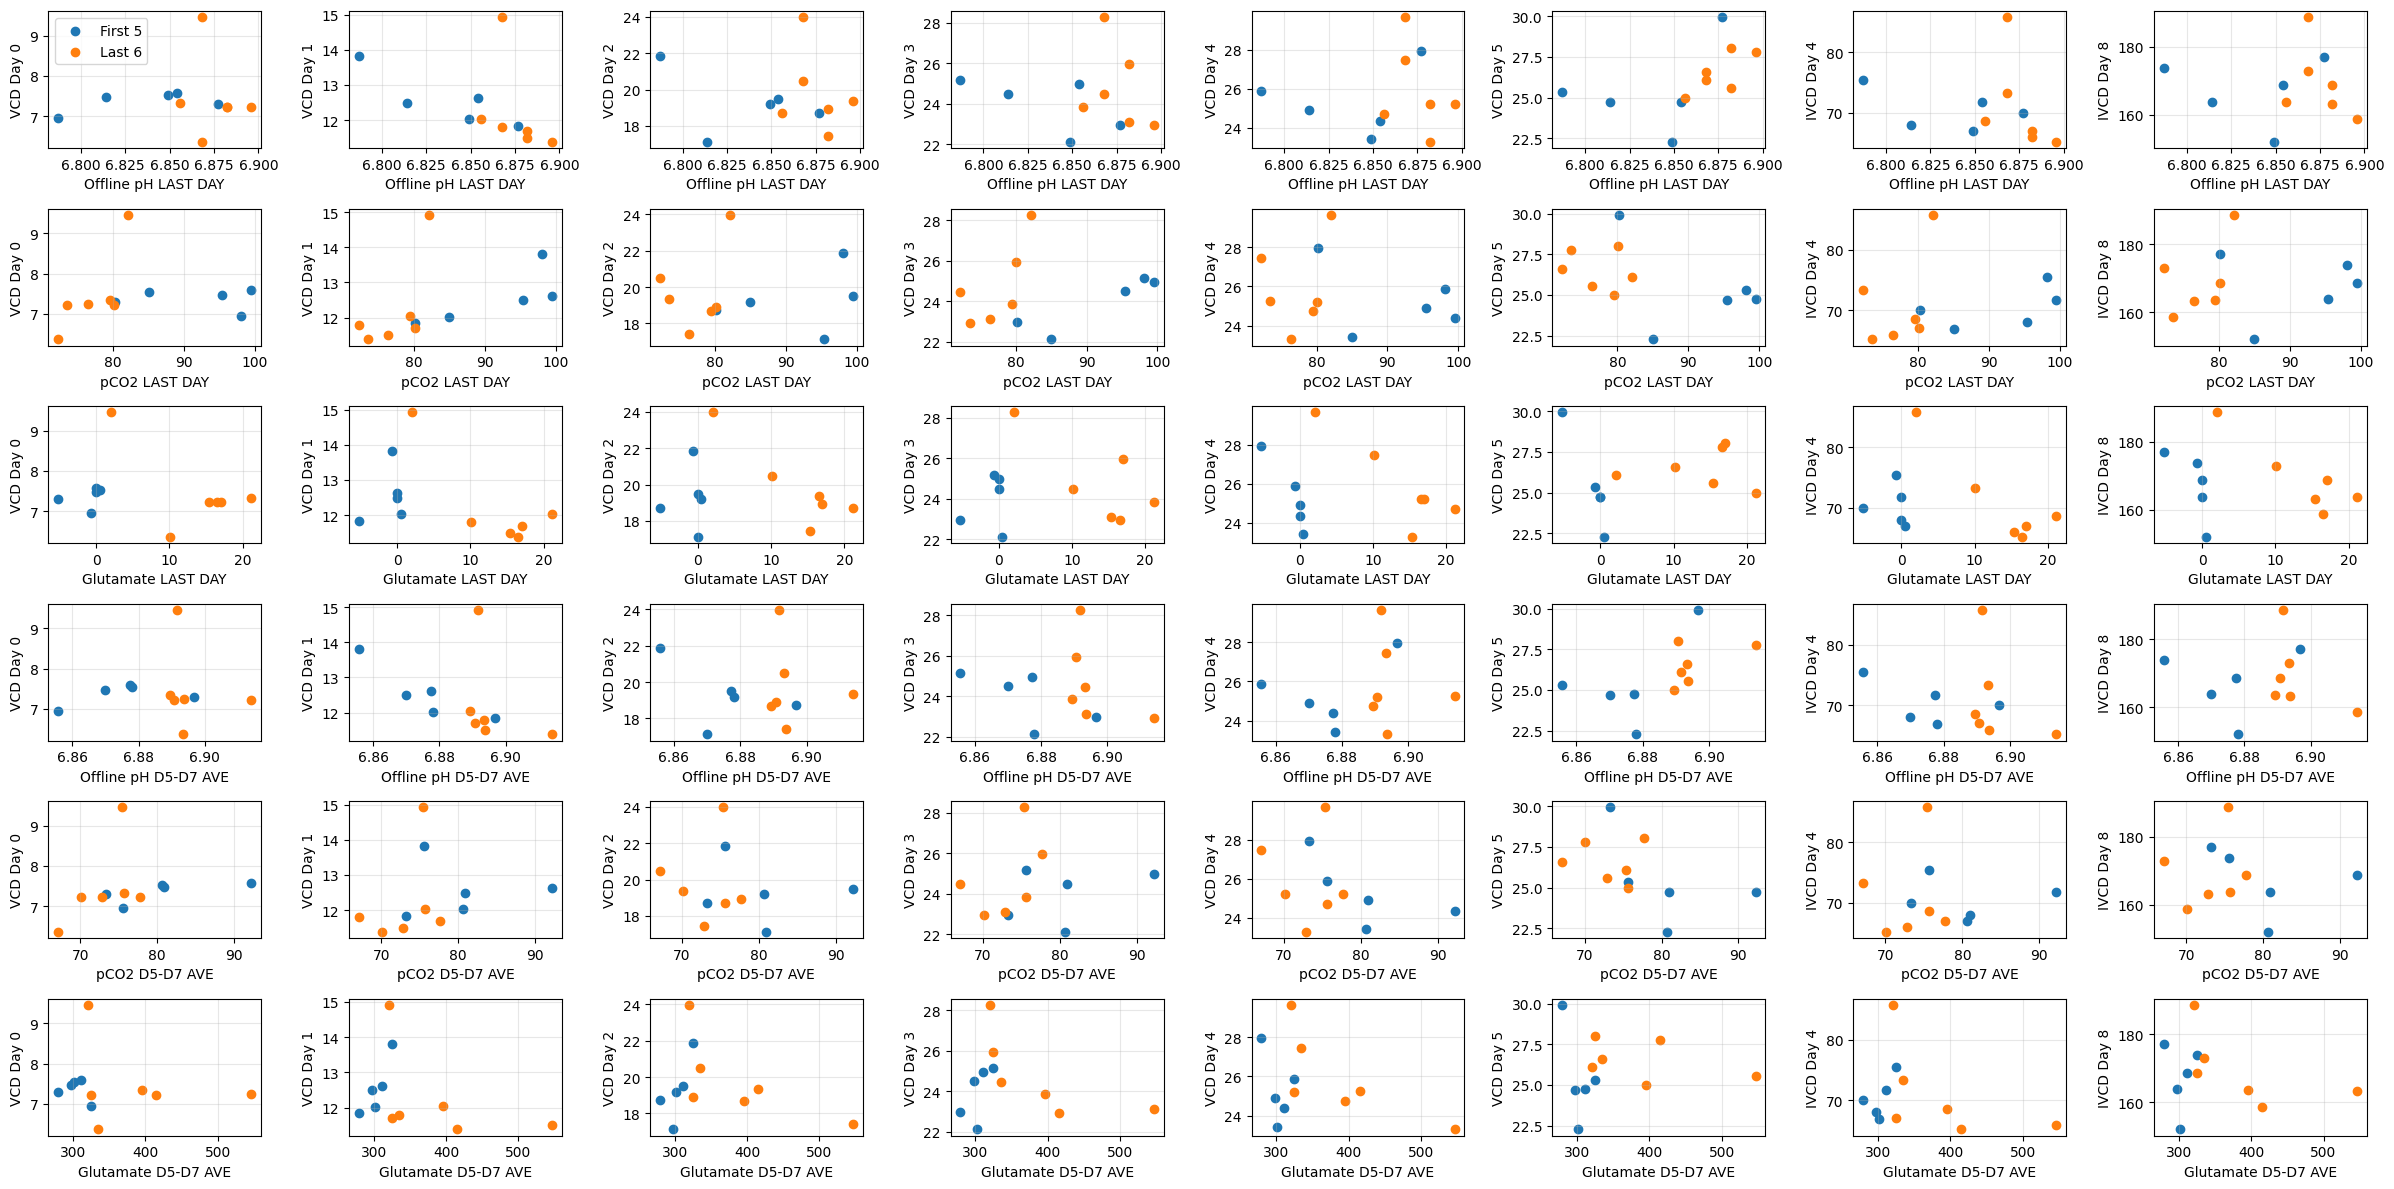

In [10]:
sub_df = merged

fig, axs = plt.subplots(6, 8, figsize = (24, 12))

for row_idx, col_a in enumerate(merged.columns[1:7]):
    for col_idx, col_b in enumerate(merged.columns[7:]):
        ax = axs[row_idx, col_idx]
        ax.scatter(merged[col_a][:5], merged[col_b][:5], label = "First 5")
        ax.scatter(merged[col_a][5:], merged[col_b][5:], label = "Last 6")
        ax.grid(alpha = 0.3)
        ax.set_xlabel(col_a)
        ax.set_ylabel(col_b)

        if (row_idx == 0) and (col_idx == 0):
            ax.legend(loc = "upper left")
fig.tight_layout()

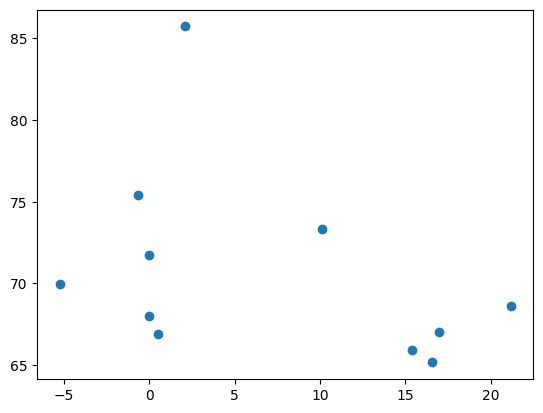

In [11]:
plt.scatter(merged["Glutamate LAST DAY"], merged["IVCD Day 4"])

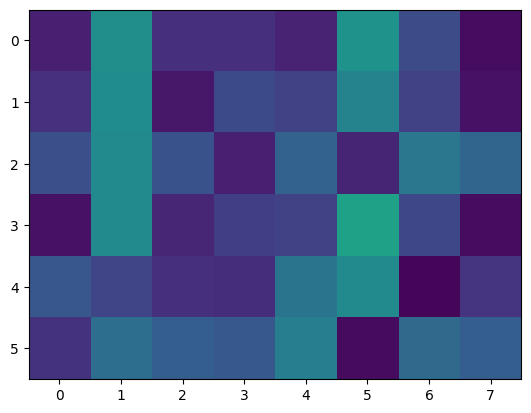

In [12]:
title = "Full"
sub_df = merged
sub_df = sub_df[sub_df.columns[1:]].corr()[:6][sub_df.columns[7:]]
x = sub_df.index.tolist()
y = sub_df.columns.tolist()

plt.imshow(sub_df.abs().to_numpy(), vmin = 0, vmax = 1)

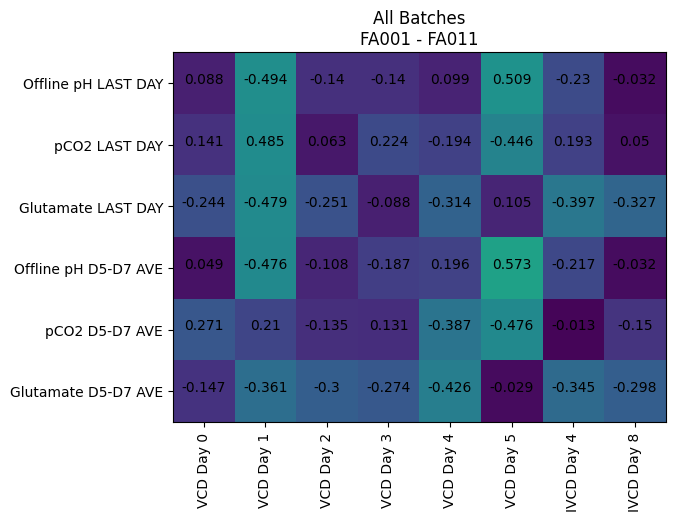

In [13]:
sub_df = merged
sub_df = sub_df[sub_df.columns[1:]].corr()[:6][sub_df.columns[7:]]
x = sub_df.index.tolist()
y = sub_df.columns.tolist()

arr = sub_df.to_numpy()
plt.imshow(sub_df.abs().to_numpy(), vmin = 0, vmax = 1)
plt.yticks(range(6), x)
plt.xticks(range(8), y, rotation = 90)

plt.title("All Batches\nFA001 - FA011")
for i in range(6):
    for j in range(8):
        plt.text(j, i, round(arr[i, j], 3), horizontalalignment = "center")

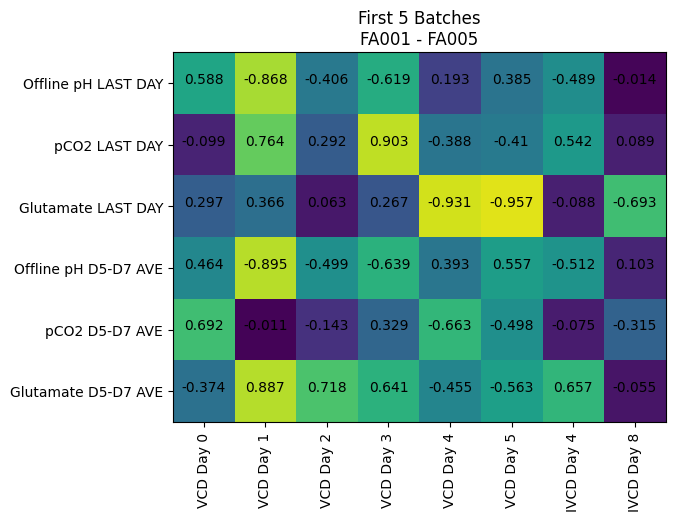

In [14]:
sub_df = merged[:5]
sub_df = sub_df[sub_df.columns[1:]].corr()[:6][sub_df.columns[7:]]
x = sub_df.index.tolist()
y = sub_df.columns.tolist()

arr = sub_df.to_numpy()
plt.imshow(sub_df.abs().to_numpy(), vmin = 0, vmax = 1)
plt.yticks(range(6), x)
plt.xticks(range(8), y, rotation = 90)

plt.title("First 5 Batches\nFA001 - FA005")
for i in range(6):
    for j in range(8):
        plt.text(j, i, round(arr[i, j], 3), horizontalalignment = "center")

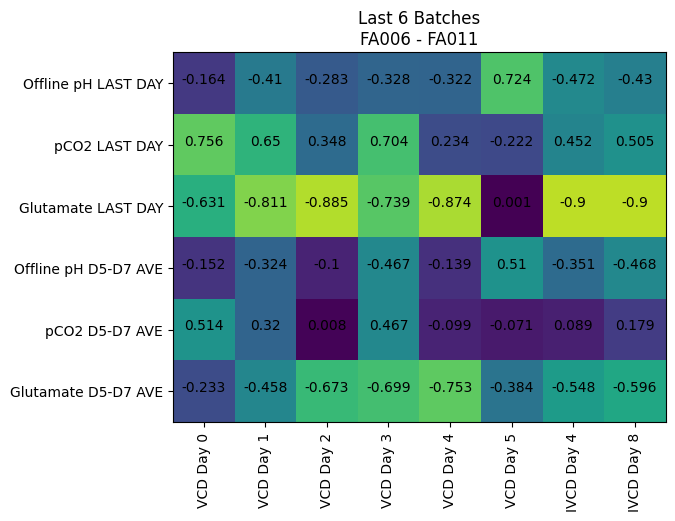

In [15]:
sub_df = merged[5:]
sub_df = sub_df[sub_df.columns[1:]].corr()[:6][sub_df.columns[7:]]
x = sub_df.index.tolist()
y = sub_df.columns.tolist()

arr = sub_df.to_numpy()
plt.imshow(sub_df.abs().to_numpy(), vmin = 0, vmax = 1)
plt.yticks(range(6), x)
plt.xticks(range(8), y, rotation = 90)

plt.title("Last 6 Batches\nFA006 - FA011")
for i in range(6):
    for j in range(8):
        plt.text(j, i, round(arr[i, j], 3), horizontalalignment = "center")

online, offline, and ph offset for VCD and IVCD

- Day 1 - 4
- Average D1-D4

0520 Slides
- Show First 5 baftches too

In [16]:
n_df

,Batch,VCD Day 0,VCD Day 1,VCD Day 2,VCD Day 3,VCD Day 4,VCD Day 5,IVCD Day 4,IVCD Day 8
0,FA001,7.53,12.03,19.19,22.11,23.43,22.27,66.900000,151.940000
1,FA002,7.59,12.63,19.50,24.96,24.37,24.76,71.747344,168.595042
2,FA003,7.47,12.50,17.12,24.50,24.92,24.70,68.033330,163.767955
3,FA004,7.30,11.84,18.74,22.97,27.96,29.93,69.970358,176.971701
4,FA005,6.95,13.82,21.87,25.17,25.89,25.32,75.440194,173.769851
5,FA006,6.36,11.80,20.49,24.47,27.46,26.58,73.336042,172.953729
6,FA007,9.46,14.92,23.97,28.27,29.65,26.11,85.734882,188.620979
7,FA008,7.23,11.70,18.92,25.95,25.23,28.05,67.021156,168.653760
8,FA009,7.24,11.50,17.44,23.11,23.29,25.56,65.956250,163.241747
9,FA010,7.23,11.38,19.35,22.93,25.25,27.78,65.162122,158.579163


In [17]:
nstep_ts.iloc[0]

Batch                                                                                  FA001
Run                                                         FA001_MCALR N-PROD 2000L_1003145
Process Day                                                                                0
Process Time [h]                                                                         0.0
Ammonia [mg/L]                                                                           NaN
Bolus Feed A Daily Qty [kg]                                                              NaN
Bolus Glucose Daily Qty [kg]                                                             NaN
Bolus Feed B Daily Qty [kg]                                                              NaN
Glucose [mg/L]                                                                           NaN
Glutamate [mg/L]                                                                         NaN
Glutamine [mg/L]                                                      

In [18]:
cols = ["Batch", "Process Day", "Offline pH preadusjtement [dimensionless]", "Online pH primary probe preadusjtement [dimensionless]", "pH offset []"]
qwe = nstep_ts[cols]
qwe = qwe.groupby(["Batch", "Process Day"]).max().reset_index()
qwe_1 = qwe[qwe["Process Day"] < 5]

sub_dfs = None
for i in range(5):
    qwe_1 = qwe[qwe["Process Day"] == i].copy()
    qwe_1.columns = ["Batch", "Process Day", f"Offline pH D{i}", f"Online pH D{i}", f"pH Offset D{i}"]
    qwe_1.drop("Process Day", axis = 1, inplace = True)

    if sub_dfs is None:
        sub_dfs = qwe_1
    else:
        sub_dfs = pd.merge(sub_dfs, qwe_1, on = "Batch")
ask_2 = sub_dfs.copy()
for col in ["Offline pH", "Online pH", "pH Offset"]:
    ask_2[f"{col} Mean D0-D4"] = ask_2[[f"{col} D{i}" for i in range(5)]].mean(axis = 1).tolist()
ask_2 = ask_2[["Batch"] + sorted(ask_2.columns[1:])]
ask_2

,Batch,Offline pH D0,Offline pH D1,Offline pH D2,Offline pH D3,Offline pH D4,Offline pH Mean D0-D4,Online pH D0,Online pH D1,Online pH D2,Online pH D3,Online pH D4,Online pH Mean D0-D4,pH Offset D0,pH Offset D1,pH Offset D2,pH Offset D3,pH Offset D4,pH Offset Mean D0-D4
0,FA001,7.047,6.896,6.838,6.911,6.982,6.9348,7.04,6.99,6.95,6.96,7.02,6.992,-0.048199,0.075332,0.052195,-0.010365,-0.021498,0.009493
1,FA002,7.029,6.891,6.827,6.931,6.960,6.9276,7.03,6.94,6.89,7.00,7.02,6.976,-0.044260,0.105553,0.004948,0.009688,0.000287,0.015243
2,FA003,7.048,6.909,6.832,6.911,6.967,6.9334,7.04,6.99,6.93,7.02,7.05,7.006,-0.054044,0.096284,0.039135,0.049600,0.023311,0.030857
3,FA004,7.027,6.911,6.814,6.880,6.957,6.9178,7.03,7.00,6.87,6.94,7.02,6.972,-0.057351,0.057523,-0.002863,0.000775,0.003392,0.000295
4,FA005,7.071,6.854,6.827,6.883,6.957,6.9184,7.04,6.95,6.91,6.99,7.03,6.984,-0.073359,0.036224,0.023858,0.047512,0.013839,0.009615
5,FA006,7.055,6.861,6.824,6.862,6.950,6.9104,7.04,6.96,6.87,6.95,7.03,6.970,-0.075269,0.040171,-0.012939,0.028532,0.020446,0.000188
6,FA007,7.067,6.881,6.821,6.943,6.956,6.9336,7.04,6.97,6.92,7.03,7.02,6.996,-0.061079,0.032797,0.039372,0.028297,0.004147,0.008707
7,FA008,7.039,6.899,6.798,6.862,6.949,6.9094,7.05,6.94,6.86,6.92,7.01,6.956,-0.036498,0.128000,0.002580,-0.000926,0.001673,0.018966
8,FA009,7.064,6.890,6.811,6.870,6.935,6.9140,7.04,6.99,6.89,6.96,7.05,6.986,-0.064601,0.068392,0.020061,0.031173,0.055945,0.022194
9,FA010,7.066,6.861,6.839,6.913,6.916,6.9190,7.04,6.95,6.92,7.00,7.03,6.988,-0.067980,0.029863,0.021182,0.027156,0.054056,0.012855


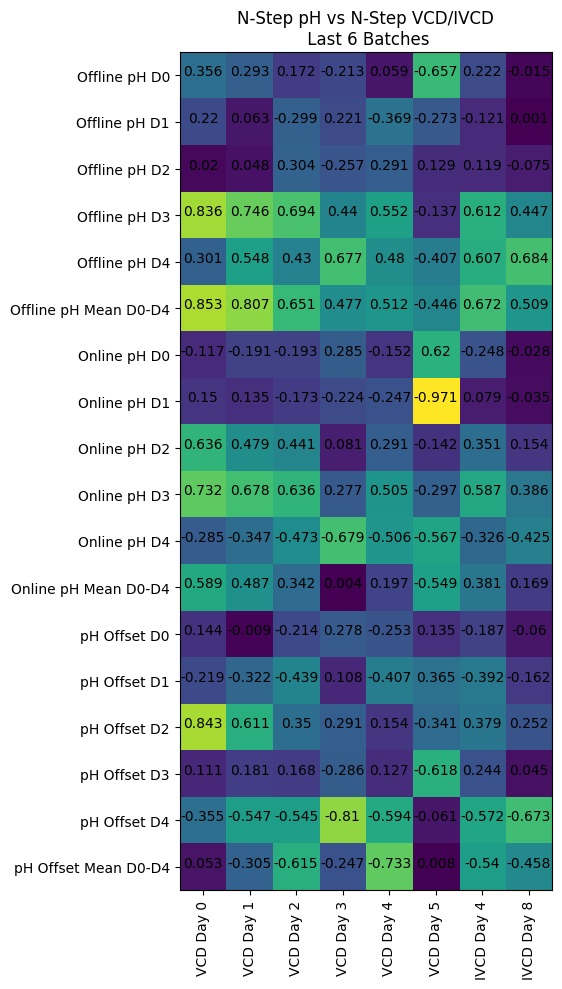

In [19]:
new_qwe = pd.merge(ask_2, n_df, on = "Batch")

new_qwe = new_qwe[5:]

corr = new_qwe[new_qwe.columns[1:]].corr()
corr_mat = corr[:-8][corr.columns[-8:]].to_numpy()
corr_abs_mat = corr[:-8][corr.columns[-8:]].abs().to_numpy()

plt.figure(figsize = (9, 10))
plt.imshow(corr_abs_mat)
plt.xticks(range(8), list(corr.columns[-8:]), rotation = 90)
plt.yticks(range(18), list(corr.columns[:-8]))

for i in range(8):
    for j in range(18):
        plt.text(i, j, round(corr_mat[j, i], 3), horizontalalignment = "center")
plt.title("N-Step pH vs N-Step VCD/IVCD\n Last 6 Batches")
plt.tight_layout()
plt.show()

In [20]:
sub_df.columns

Index(['VCD Day 0', 'VCD Day 1', 'VCD Day 2', 'VCD Day 3', 'VCD Day 4',
       'VCD Day 5', 'IVCD Day 4', 'IVCD Day 8'],
      dtype='object')

In [21]:
new_qwe

,Batch,Offline pH D0,Offline pH D1,Offline pH D2,Offline pH D3,Offline pH D4,Offline pH Mean D0-D4,Online pH D0,Online pH D1,Online pH D2,...,pH Offset D4,pH Offset Mean D0-D4,VCD Day 0,VCD Day 1,VCD Day 2,VCD Day 3,VCD Day 4,VCD Day 5,IVCD Day 4,IVCD Day 8
5,FA006,7.055,6.861,6.824,6.862,6.950,6.9104,7.04,6.96,6.87,...,0.020446,0.000188,6.36,11.80,20.49,24.47,27.46,26.58,73.336042,172.953729
6,FA007,7.067,6.881,6.821,6.943,6.956,6.9336,7.04,6.97,6.92,...,0.004147,0.008707,9.46,14.92,23.97,28.27,29.65,26.11,85.734882,188.620979
7,FA008,7.039,6.899,6.798,6.862,6.949,6.9094,7.05,6.94,6.86,...,0.001673,0.018966,7.23,11.70,18.92,25.95,25.23,28.05,67.021156,168.653760
8,FA009,7.064,6.890,6.811,6.870,6.935,6.9140,7.04,6.99,6.89,...,0.055945,0.022194,7.24,11.50,17.44,23.11,23.29,25.56,65.956250,163.241747
9,FA010,7.066,6.861,6.839,6.913,6.916,6.9190,7.04,6.95,6.92,...,0.054056,0.012855,7.23,11.38,19.35,22.93,25.25,27.78,65.162122,158.579163
10,FA011,7.069,6.894,6.812,6.896,6.953,6.9248,7.04,6.99,6.89,...,0.017429,0.013456,7.34,12.04,18.70,23.86,24.72,24.98,68.620000,163.600000


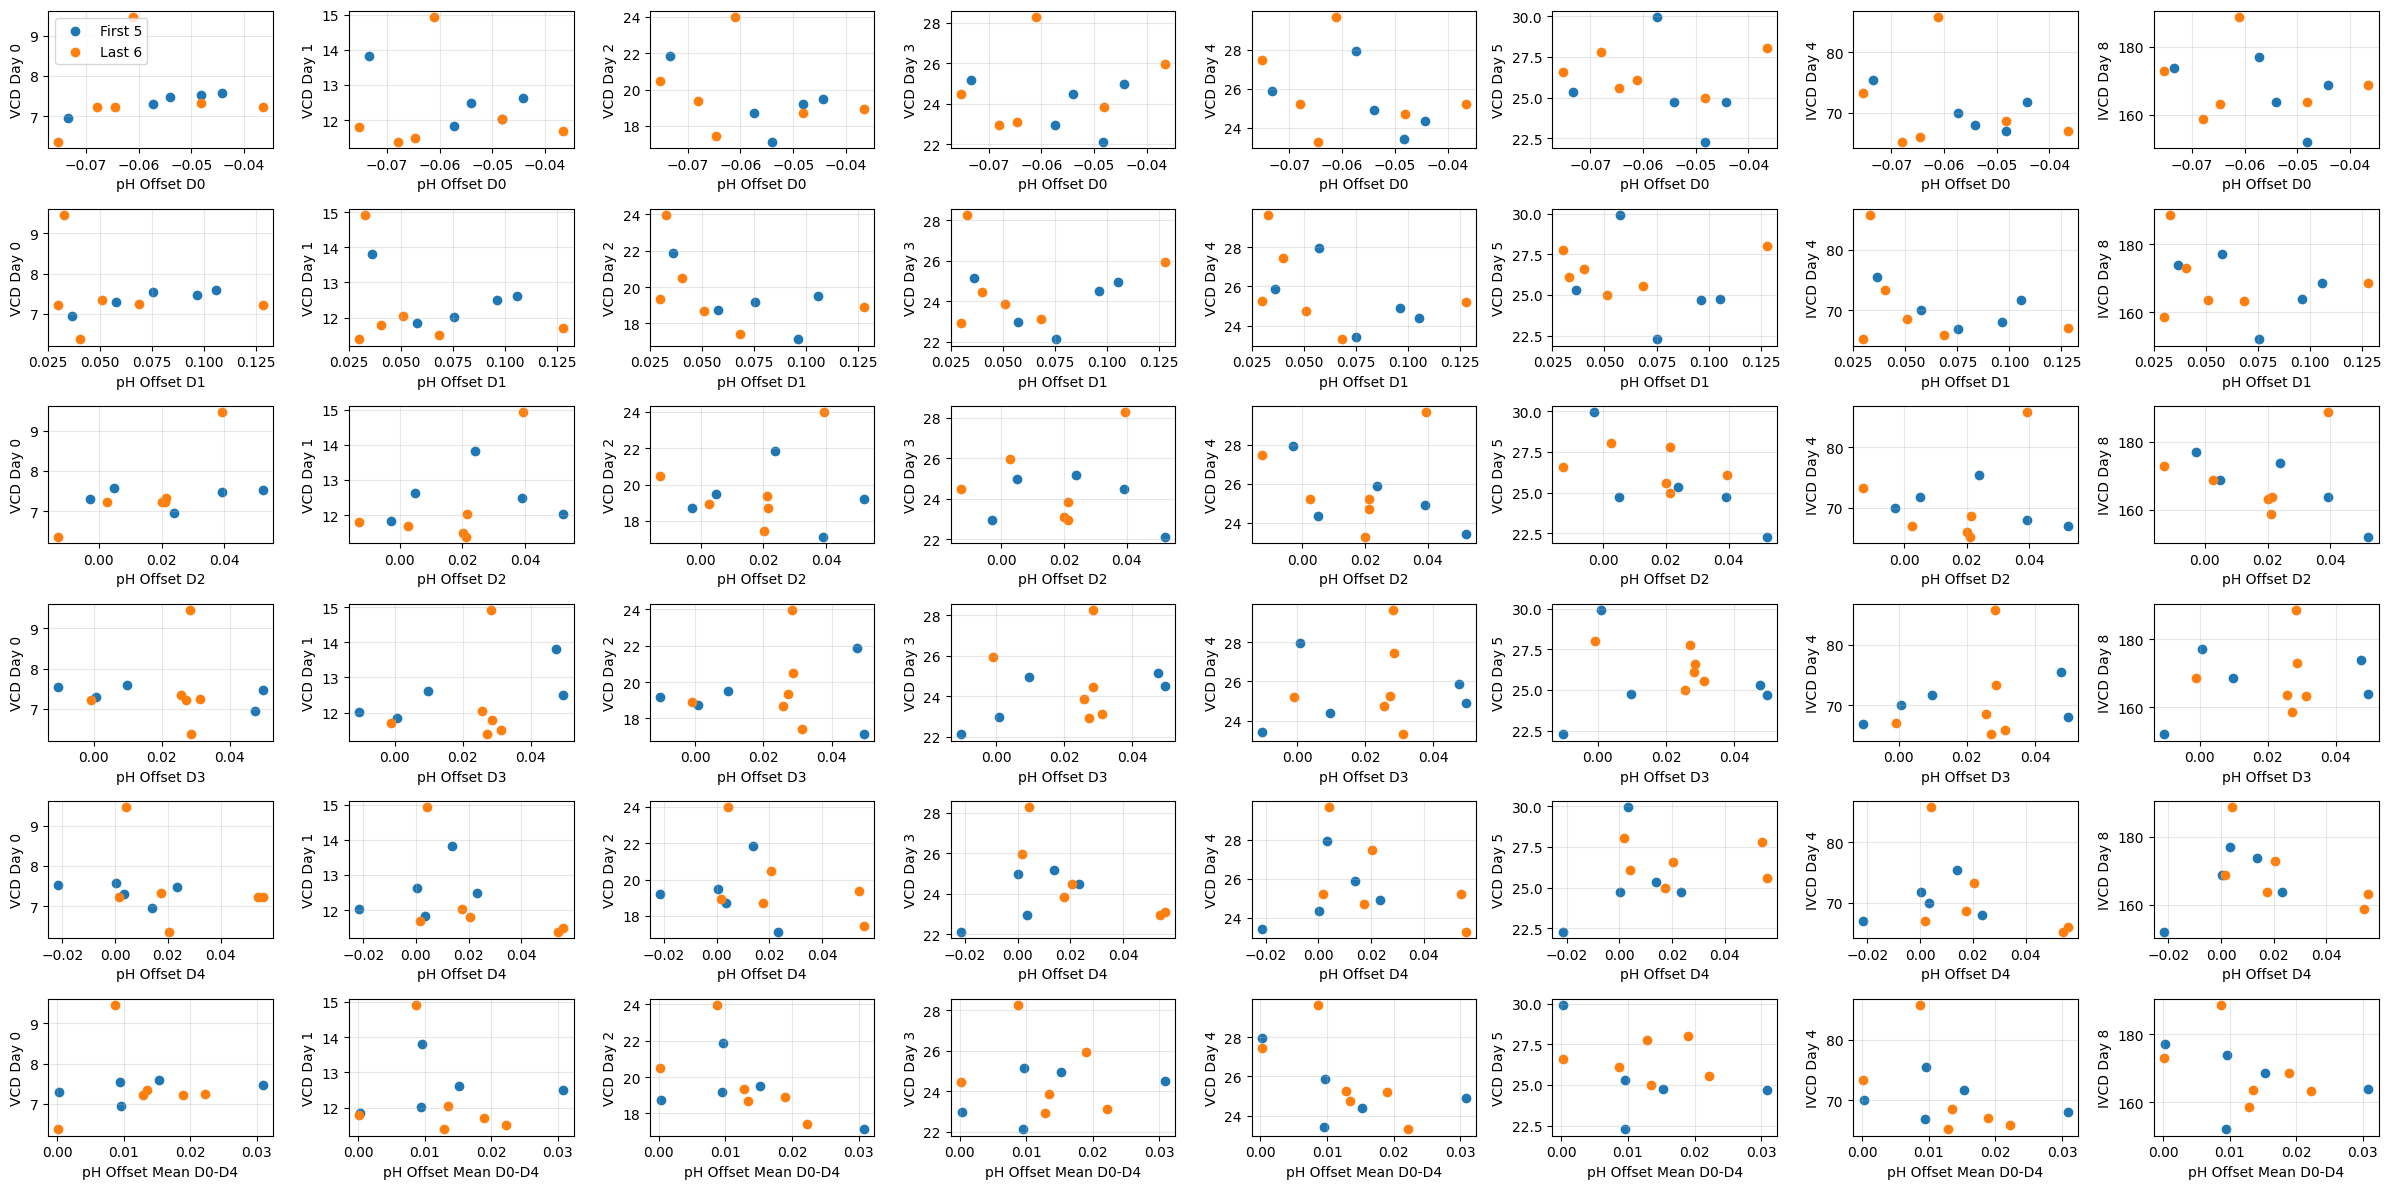

In [22]:
new_qwe = pd.merge(ask_2, n_df, on = "Batch")
sub_df = new_qwe

fig, axs = plt.subplots(6, 8, figsize = (24, 12))

idx = 18
for row_idx, col_a in enumerate(sub_df.columns[13:19]):
    for col_idx, col_b in enumerate(sub_df.columns[19:]):
        ax = axs[row_idx, col_idx]
        ax.scatter(sub_df[col_a][:5], sub_df[col_b][:5], label = "First 5")
        ax.scatter(sub_df[col_a][5:], sub_df[col_b][5:], label = "Last 6")
        ax.grid(alpha = 0.3)
        ax.set_xlabel(col_a)
        ax.set_ylabel(col_b)

        if (row_idx == 0) and (col_idx == 0):
            ax.legend(loc = "upper left")
fig.tight_layout()

In [ ]:
nstep

In [24]:
n_df

,Batch,VCD Day 0,VCD Day 1,VCD Day 2,VCD Day 3,VCD Day 4,VCD Day 5,IVCD Day 4,IVCD Day 8
0,FA001,7.53,12.03,19.19,22.11,23.43,22.27,66.900000,151.940000
1,FA002,7.59,12.63,19.50,24.96,24.37,24.76,71.747344,168.595042
2,FA003,7.47,12.50,17.12,24.50,24.92,24.70,68.033330,163.767955
3,FA004,7.30,11.84,18.74,22.97,27.96,29.93,69.970358,176.971701
4,FA005,6.95,13.82,21.87,25.17,25.89,25.32,75.440194,173.769851
5,FA006,6.36,11.80,20.49,24.47,27.46,26.58,73.336042,172.953729
6,FA007,9.46,14.92,23.97,28.27,29.65,26.11,85.734882,188.620979
7,FA008,7.23,11.70,18.92,25.95,25.23,28.05,67.021156,168.653760
8,FA009,7.24,11.50,17.44,23.11,23.29,25.56,65.956250,163.241747
9,FA010,7.23,11.38,19.35,22.93,25.25,27.78,65.162122,158.579163
